In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
# Load the Iris dataset
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSpecies Count:")
print(df['species_name'].value_counts())

Shape of dataset: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa  

Species Count:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


In [3]:
# Split data for training
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 120
Testing samples:  30


In [4]:
# Train 3 models and compare
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

print("=" * 50)
print("     MODEL ACCURACY COMPARISON")
print("=" * 50)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:25s} → Accuracy: {acc*100:.2f}%")

print("=" * 50)
best = max(results, key=results.get)
print(f"\n🏆 Best Model: {best} ({results[best]*100:.2f}%)")

     MODEL ACCURACY COMPARISON
K-Nearest Neighbors       → Accuracy: 93.33%
Decision Tree             → Accuracy: 93.33%
Random Forest             → Accuracy: 90.00%

🏆 Best Model: K-Nearest Neighbors (93.33%)


📊 Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.83      1.00      0.91        10
   Virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



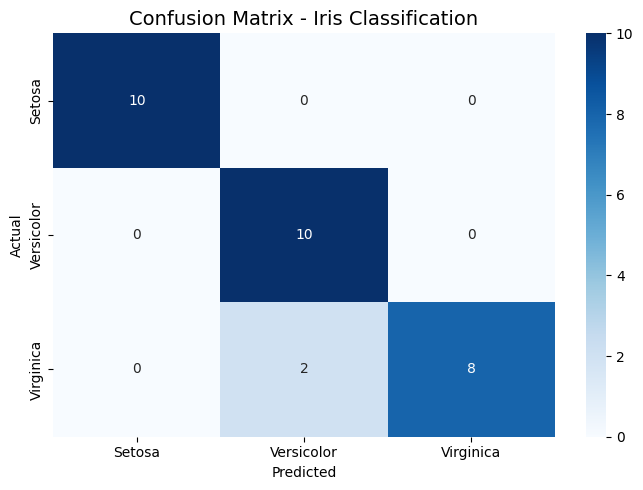

✅ Task 1 Complete!


In [5]:
# Final report + chart
best_model = models['K-Nearest Neighbors']
y_pred_best = best_model.predict(X_test_scaled)

print("📊 Classification Report:")
print(classification_report(y_test, y_pred_best,
      target_names=['Setosa', 'Versicolor', 'Virginica']))

# Confusion Matrix chart
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Confusion Matrix - Iris Classification', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print("✅ Task 1 Complete!")